# E-Commerce Sales & Customer Analytics

## 03 — Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned
e-commerce datasets and identify meaningful patterns in:

- Sales and revenue
- Product performance
- Customer behavior
- Payment methods
- Delivery performance
- Customer reviews

The analysis is structured around business questions to identify
actionable insights that can support e-commerce decision-making.

### 2. Import Libraries

In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### 3. Load Cleaned Data

In [113]:
data_path = "../data/processed/"

customers = pd.read_csv(data_path + "customers_clean.csv")
orders = pd.read_csv(data_path + "orders_clean.csv")
order_items = pd.read_csv(data_path + "order_items_clean.csv")
products = pd.read_csv(data_path + "products_clean.csv")
payments = pd.read_csv(data_path + "payments_clean.csv")
reviews = pd.read_csv(data_path + "reviews_clean.csv")
sellers = pd.read_csv(data_path + "sellers_clean.csv")

In [114]:
order_date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

In [115]:
reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date'],
    errors='coerce'
)

reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp'],
    errors='coerce'
)

order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce'
)

### 4. Prepare Data for Analysis

In [116]:
sales = order_items.merge(
    orders[['order_id', 'customer_id', 'order_status',
            'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

In [117]:
sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51


In [118]:
sales.shape

(112650, 10)

### 5. Sales & Revenue Analysis

###  5.1 Total Revenue

In [119]:
total_revenue = order_items['price'].sum()
total_revenue

np.float64(13591643.7)

### 5.2 Total Orders

In [120]:
total_orders = orders['order_id'].nunique()
total_orders

99441

In [121]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### 5.3 Delivered Revenue

In [122]:
delivered_orders = orders[
    orders['order_status'] == 'delivered'
].copy()

In [ ]:
# Filter the sales DataFrame directly for 'delivered' and sum the price
delivered_revenue = sales[
    sales['order_status'] == 'delivered'
    ]['price'].sum()

print(delivered_revenue)


### 5.4 Average Order Value

In [170]:
delivered_orders_count = delivered_orders['order_id'].nunique()
delivered_orders_count 

96478

In [171]:
delivered_aov = round(
    delivered_revenue / delivered_orders_count,
    2
)

delivered_aov

np.float64(137.04)

### Average Order Value

Average Order Value (AOV) represents the average revenue generated
per order.

For the main business analysis, delivered orders are used to avoid
including orders that were canceled or unavailable.

###  5.5 Orders Over Time

In [127]:
orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

In [128]:
monthly_orders = (
    orders.groupby('order_month')['order_id']
    .nunique()
    .reset_index(name='orders')
)

monthly_orders.head()

,order_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


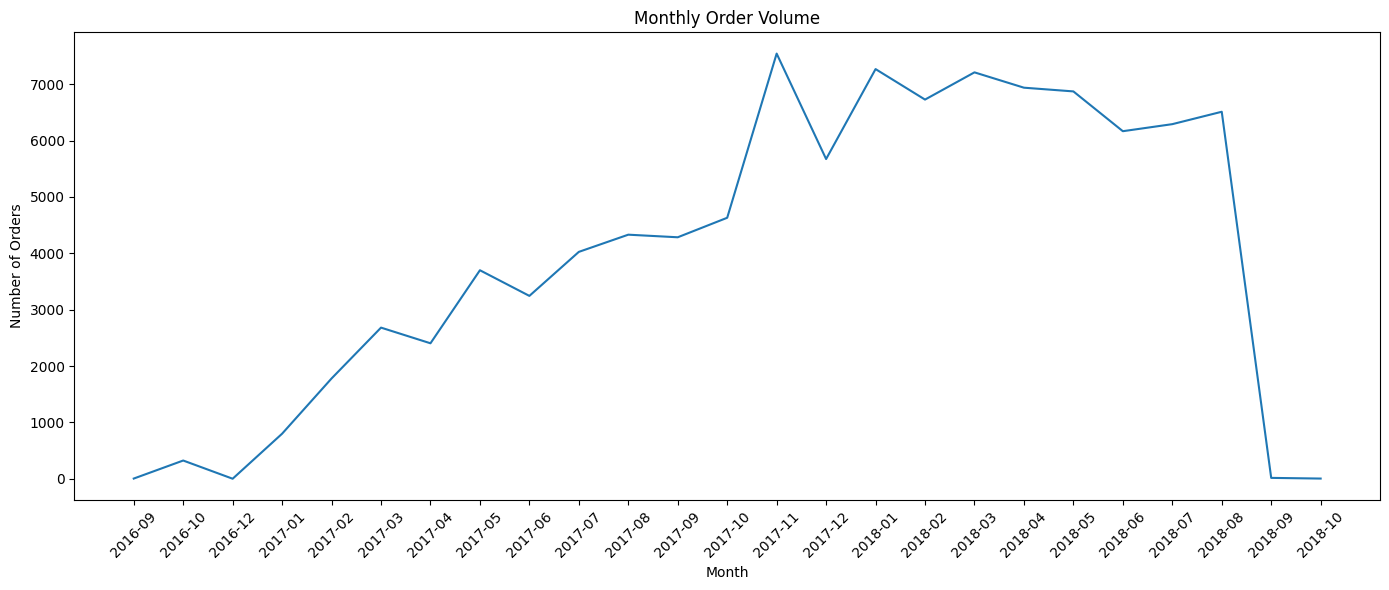

In [129]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x='order_month',
    y='orders'
)

plt.xticks(rotation=45)
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 5.6 Revenue Over Time

In [130]:
sales['order_month'] = (
     sales['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

In [131]:
monthly_revenue = (
    sales.groupby('order_month')['price']
    .sum()
    .reset_index(name='revenue')
)

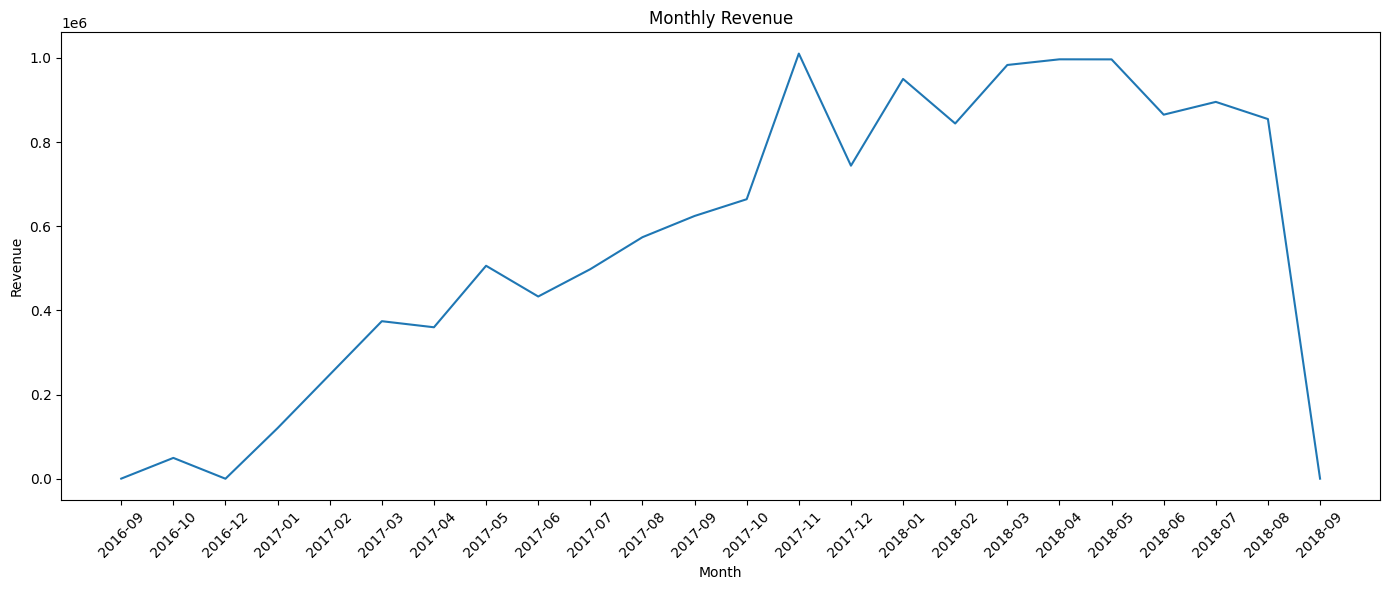

In [132]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='revenue'
)

plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Interpretation

The monthly revenue trend shows how sales performance changed over
time. Periods of increasing revenue can indicate stronger demand,
while declines may indicate seasonal effects or changes in customer
purchasing behavior.

###  5.4 Average Order Value

### 6. Product Analysis

In [133]:
sales_products = sales.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

###  6.1 Top Product Categories

In [134]:
category_volume = (sales_products.groupby('product_category_name').size().sort_values(ascending=False).head(10))
category_volume 

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
dtype: int64

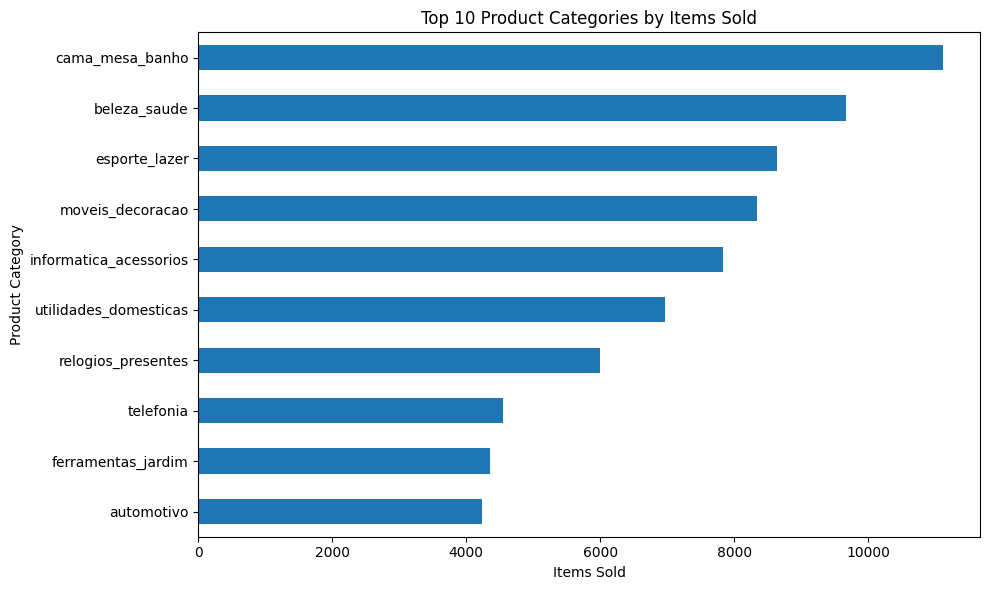

In [135]:
plt.figure(figsize=(10,6))

category_volume.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Items Sold')
plt.xlabel('Items Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

###  6.2 Revenue by Category

In [136]:
category_revenue = (
    sales_products
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

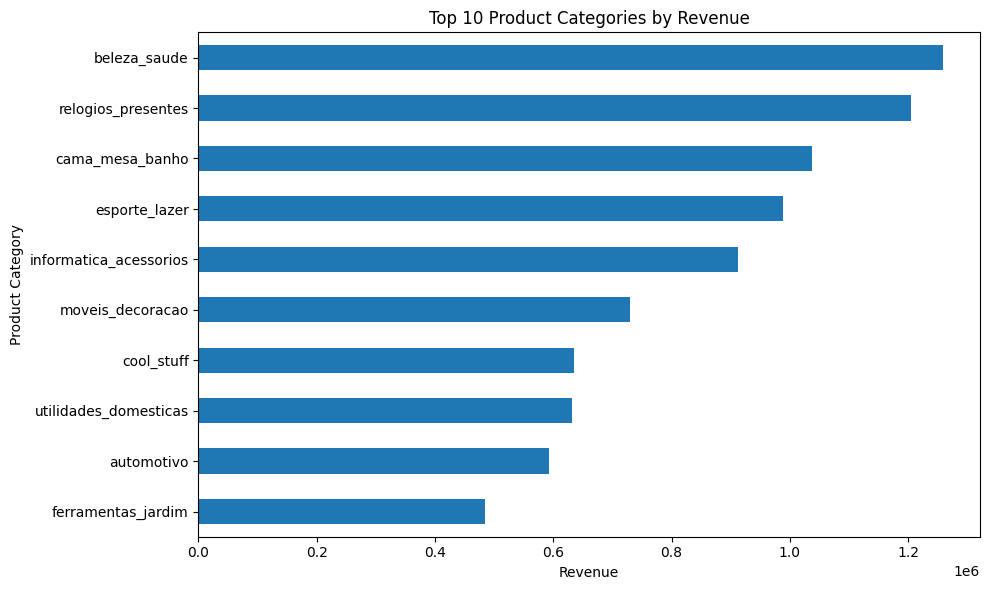

In [137]:
plt.figure(figsize=(10, 6))

category_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

###  6.3 Order Volume by Category

In [138]:
category_orders = (
    sales_products
    .groupby('product_category_name')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

category_orders

product_category_name
cama_mesa_banho           9417
beleza_saude              8836
esporte_lazer             7720
informatica_acessorios    6689
moveis_decoracao          6449
utilidades_domesticas     5884
relogios_presentes        5624
telefonia                 4199
automotivo                3897
brinquedos                3886
Name: order_id, dtype: int64

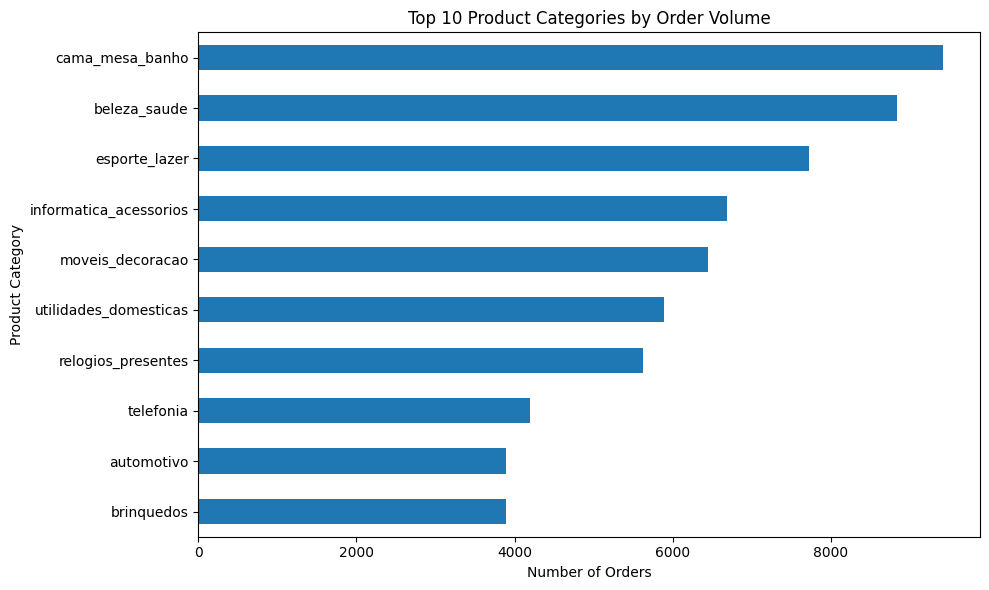

In [139]:
plt.figure(figsize=(10, 6))

category_orders.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### 7. Customer Analysis

In [140]:
sales_customers = sales.merge(
    customers[
        ['customer_id', 'customer_state', 'customer_city']
    ],
    on='customer_id',
    how='left'
)

###  7.1 Customer Distribution

In [141]:
customer_city = (
    customers['customer_city']
    .value_counts()
    .head(10)
)

customer_city

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64

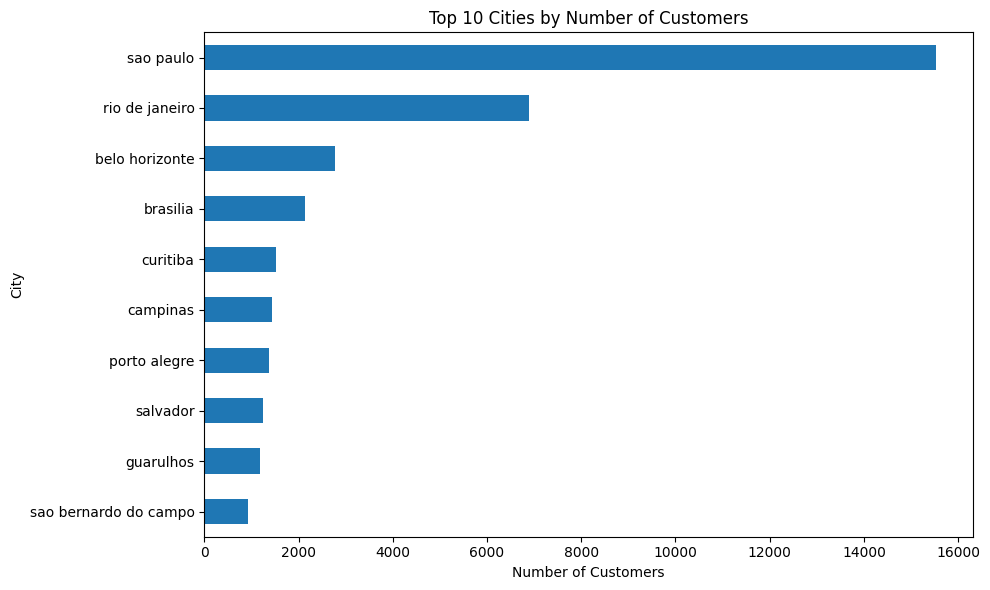

In [142]:
plt.figure(figsize=(10, 6))

customer_city.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('City')

plt.tight_layout()
plt.show()

###  7.2 Customers by State

In [143]:
customer_state = (
    customers['customer_state']
    .value_counts()
    .head(10)
)

customer_state

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

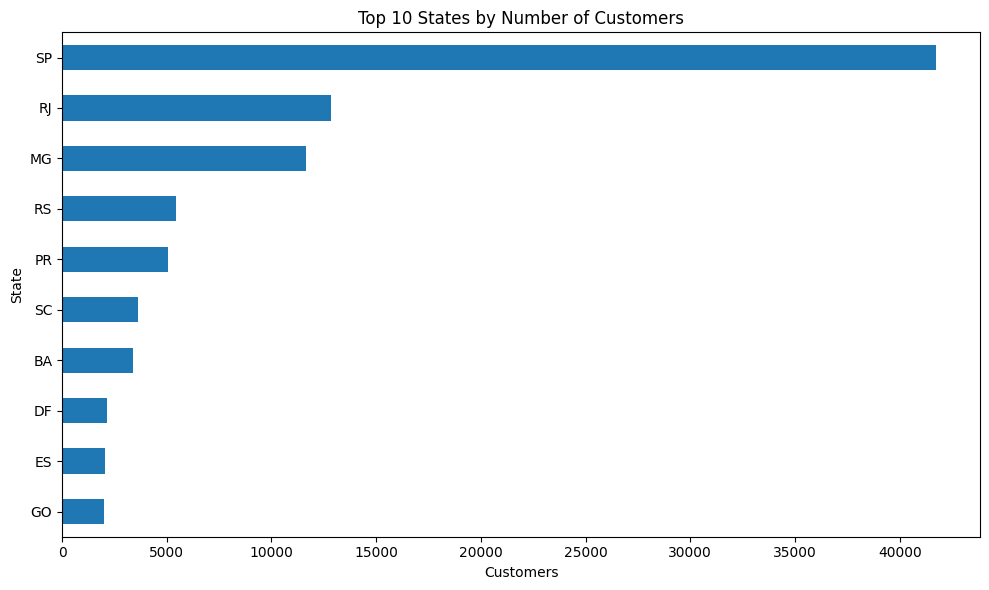

In [144]:
plt.figure(figsize=(10, 6))

customer_state.sort_values().plot(kind='barh')

plt.title('Top 10 States by Number of Customers')
plt.xlabel('Customers')
plt.ylabel('State')

plt.tight_layout()
plt.show()

###  7.3 Repeat Customers

In [145]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [146]:
repeat_customers = (
    customers['customer_unique_id']
    .value_counts()
)

repeat_customers.head()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
Name: count, dtype: int64

In [147]:
repeat_customer_count = (
    repeat_customers > 1
).sum()

repeat_customer_count 

np.int64(2997)

In [148]:
repeat_customer_rate = ( 
    repeat_customer_count / customers['customer_unique_id'].nunique() 
) * 100 

repeat_customer_rate

np.float64(3.1187562437562435)

### 8. Payment Analysis

###  8.1 Payment Methods

In [149]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

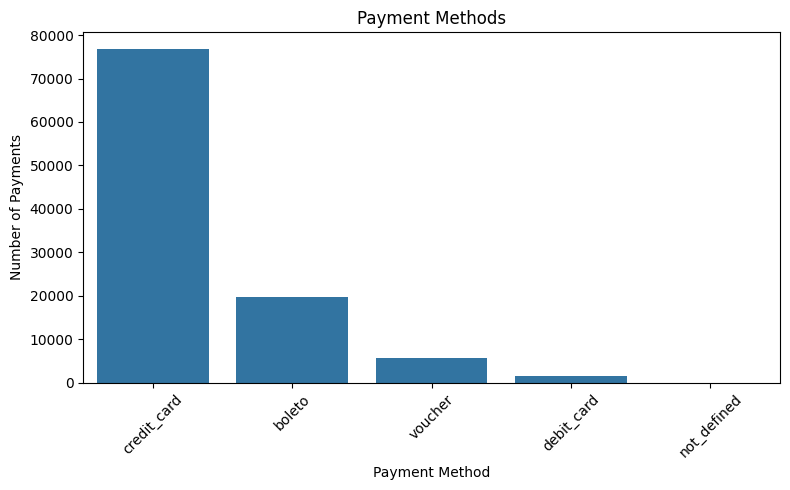

In [150]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=payments,
    x='payment_type',
    order=payments['payment_type'].value_counts().index
)

plt.title('Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Payments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###  8.2 Payment Installments

In [151]:
payments['payment_installments'].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

In [152]:
payments.groupby(
    'payment_type'
)['payment_installments'].mean().sort_values(ascending=False)

payment_type
credit_card    3.507155
boleto         1.000000
debit_card     1.000000
not_defined    1.000000
voucher        1.000000
Name: payment_installments, dtype: float64

### 9. Delivery Performance

###  9.1 Delivery Time

In [153]:
delivered_orders['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

###  9.2 Late Deliveries

In [154]:
delivered_orders['is_late'] = (
    delivered_orders['delivery_delay_days'] > 0
)

In [155]:
delivered_orders['is_late'].value_counts()

is_late
False    89944
True      6534
Name: count, dtype: int64

In [156]:
late_delivery_rate = (
    delivered_orders['is_late'].mean() * 100
)

late_delivery_rate

np.float64(6.77252845208234)

In [157]:
delivered_orders['delivery_days'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

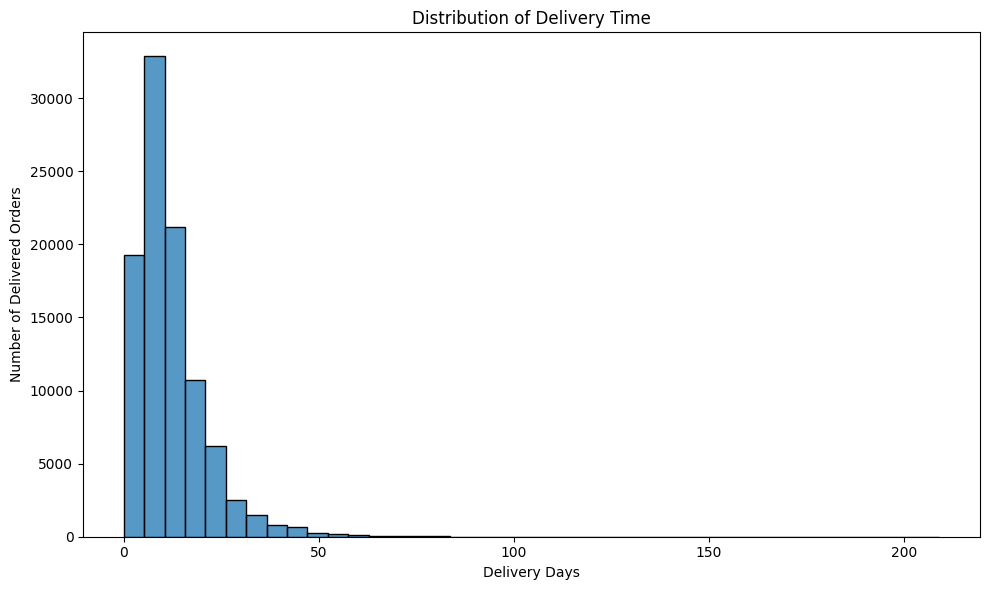

In [158]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=delivered_orders,
    x='delivery_days',
    bins=40
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Delivered Orders')

plt.tight_layout()
plt.show()

###  9.3 Delivery Performance by Category

In [159]:
delivery_category = (
    order_items
    .merge(
        delivered_orders[
            [
                'order_id',
                'delivery_days',
                'delivery_delay_days',
                'is_late'
            ]
        ],
        on='order_id',
        how='inner'
    )
    .merge(
        products[
            ['product_id', 'product_category_name']
        ],
        on='product_id',
        how='left'
    )
)

In [160]:
category_delivery = (
    delivery_category
    .groupby('product_category_name')['delivery_days']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

category_delivery

product_category_name
moveis_escritorio                 20.386691
artigos_de_natal                  15.300000
seguros_e_servicos                15.000000
fashion_calcados                  14.933852
casa_conforto_2                   14.066667
moveis_colchao_e_estofado         13.891892
eletrodomesticos_2                13.424242
moveis_sala                       13.294949
fashion_underwear_e_moda_praia    13.275591
ferramentas_jardim                13.231959
Name: delivery_days, dtype: float64

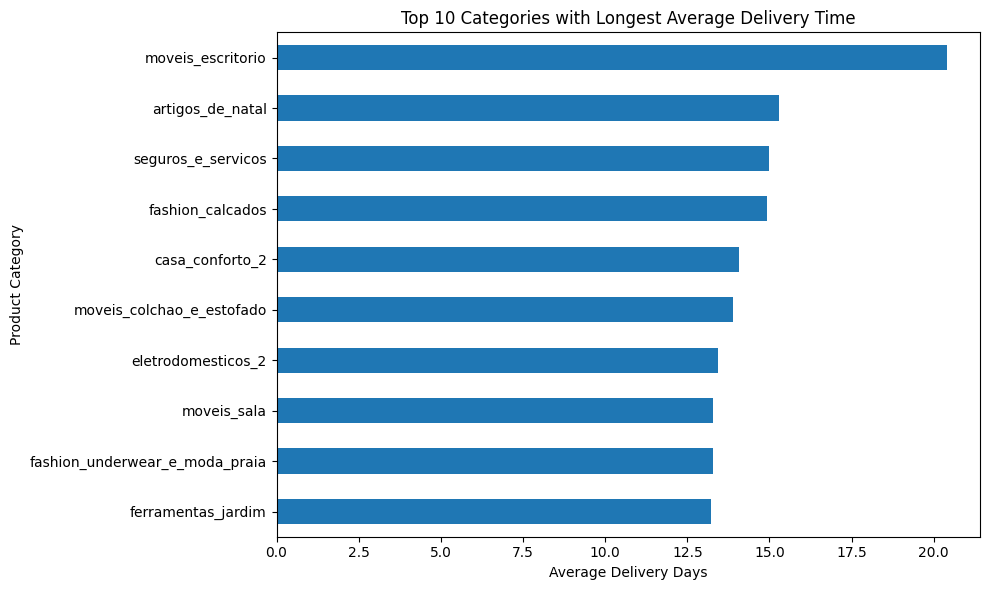

In [161]:
plt.figure(figsize=(10, 6))

category_delivery.sort_values().plot(kind='barh')

plt.title('Top 10 Categories with Longest Average Delivery Time')
plt.xlabel('Average Delivery Days')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### 10. Review Analysis

###  10.1 Review Score Distribution

In [162]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

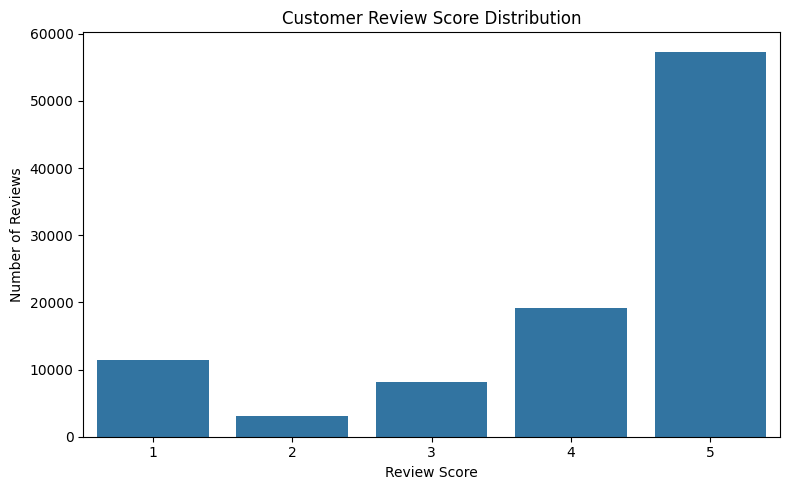

In [163]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=reviews,
    x='review_score'
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

### 10.2 Review Score vs Delivery Performance

In [164]:
order_reviews = delivered_orders[
    [
        'order_id',
        'delivery_days',
        'delivery_delay_days',
        'is_late'
    ]
].merge(
    reviews[
        ['order_id', 'review_score']
    ],
    on='order_id',
    how='inner'
)

In [165]:
review_delivery = (
    order_reviews
    .groupby('is_late')['review_score']
    .mean()
)

review_delivery

is_late
False    4.289999
True     2.271025
Name: review_score, dtype: float64

In [166]:
order_reviews.groupby(
    'review_score'
)['delivery_days'].mean()

review_score
1    20.849973
2    16.194832
3    13.793242
4    11.848054
5    10.224154
Name: delivery_days, dtype: float64

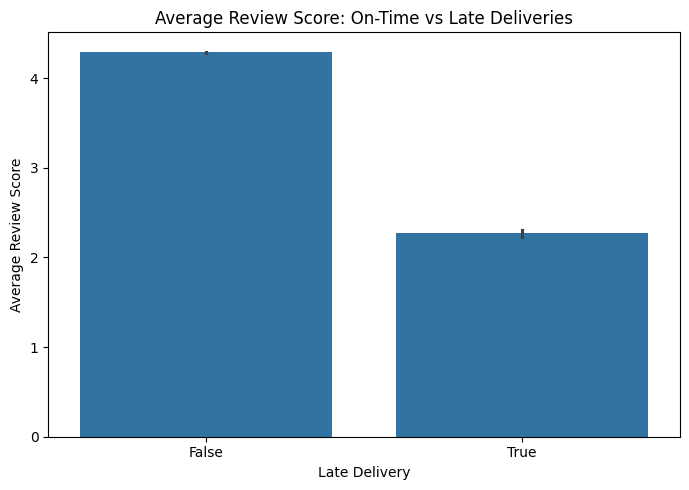

In [167]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=order_reviews,
    x='is_late',
    y='review_score'
)

plt.title('Average Review Score: On-Time vs Late Deliveries')
plt.xlabel('Late Delivery')
plt.ylabel('Average Review Score')

plt.tight_layout()
plt.show()

## 11. Key Business Insights

### Sales

* The e-commerce platform generated a total revenue of approximately **13.59 million** across **99,441 orders**.
* **96,478 orders** were successfully delivered, generating approximately **13.22 million** in revenue.
* The Average Order Value (AOV) for delivered orders was approximately **137.04**.
* Monthly revenue showed substantial growth from the early period of the dataset. Revenue increased from **49,507.66 in October 2016** to over **500,000 in May 2017**, indicating significant growth in sales activity during this period.

### Products

* **beleza_saude** was the highest-revenue product category, generating approximately **1.26 million** in revenue.
* **cama_mesa_banho** had the highest order volume, with **9,417 orders**.
* The highest-revenue category and the highest-volume category were not the same, indicating that some categories generate higher revenue per order while others generate higher sales volume.
* **relogios_presentes** generated the second-highest revenue despite having fewer orders than several other leading categories, suggesting relatively higher-value purchases.

### Customers

* The customer base was highly concentrated in **SP**, which had **41,746 customers**, significantly more than any other state.
* **RJ** and **MG** were the next largest customer markets, with **12,852** and **11,635 customers**, respectively.
* **Sao Paulo** was the city with the highest number of customers, with **15,540 customers**.
* The repeat customer rate was approximately **3.12%**, indicating that the majority of customers made only one recorded purchase during the dataset period.

### Payments

* **Credit cards** were the most commonly used payment method, with **76,795 transactions**.
* **Boleto** was the second most frequently used payment method, with **19,784 transactions**.
* Debit cards and vouchers were used considerably less frequently.
* The strong preference for credit card payments indicates that payment flexibility is an important part of the customer purchasing experience.

### Delivery

* The average delivery time for delivered orders was approximately **12.09 days**.
* Half of delivered orders were completed within **10 days**, based on the median delivery time.
* Approximately **6.77%** of delivered orders arrived later than the estimated delivery date.
* **moveis_escritorio** had the longest average delivery time among the identified categories, at approximately **20.39 days**.
* Furniture-related categories appeared among the categories with longer delivery times, indicating potential operational challenges associated with larger or more complex products.

### Customer Satisfaction

* **5-star reviews** were the most common customer rating, with **57,328 reviews**, indicating generally strong customer satisfaction.
* Customers whose orders were delivered on time or early gave an average review score of approximately **4.29**.
* Customers whose orders were delivered late gave a significantly lower average review score of approximately **2.27**.
* The substantial difference in review scores suggests a strong relationship between delivery performance and customer satisfaction.
* Improving delivery reliability could therefore have a significant positive impact on the overall customer experience and review ratings.


## 12. Next Steps

The findings from the exploratory analysis will be used to build
a business-focused dashboard.

The dashboard will summarize:

- Revenue and order KPIs
- Monthly sales trends
- Product category performance
- Customer geography
- Payment behavior
- Delivery performance
- Customer satisfaction